# Lab 4.01 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 1 - soft-drinks


The file softdrinks.xlsx categorizes 250 randomly 
selected consumers on the basis of their gender, their 
age, and their preference for our brand or a competitor's brand of a low-calorie soft drink. Use a chi-square test for independence to see whether the drink 
preference is independent of gender, and then whether 
it is independent of age.  First make a plot

Results of the main calculations:
- age vs preference
  - χ² ≈ 3.8589  
  - p-value = 0.2771
  - We do not reject H0


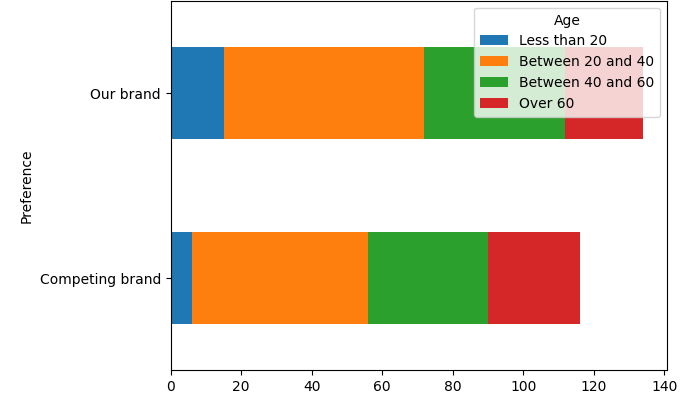



- gender vs preference
  - χ² ≈ 1.4078 
  - p-value = 0.2354
  - We do not reject H0

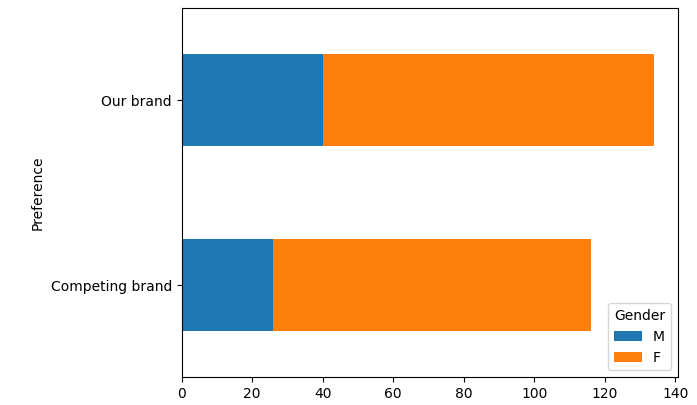

In [2]:
softdrinks = pd.read_csv(
    'https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Softdrinks.csv', 
    sep=";", index_col=0)
softdrinks.head()

,Gender,Age,Preference
Consumer,,,
1,F,Over 60,Our brand
2,F,Between 40 and 60,Our brand
3,M,Between 40 and 60,Our brand
4,F,Over 60,Competing brand
5,M,Between 20 and 40,Our brand


### Age vs Preference

In [ ]:
# Onafhankelijke veranderlijke als afhankelijke veranderlijke zijn kwalitatieve variablen
# 4 cat voor Age, 2 cat voor Preference

In [ ]:
# Stap 1
# H₀ => Geen significant verschil obv de leeftijd
# H₁ => Wel significant verschil in voorkeuren obv de leeftijd

In [4]:
# Stap 2
alpha = 0.05

In [5]:
# Stap 3 => teststatistiek = chi2
# Stap 4 => p & g berekenen

observed = pd.crosstab(df.Preference, df.Age)
observed

Age,Between 20 and 40,Between 40 and 60,Less than 20,Over 60
Preference,,,,
Competing brand,50,34,6,26
Our brand,57,40,15,22


In [6]:
chi2, p, dof, expected = stats.chi2_contingency(observed)

g = stats.chi2.isf(alpha, df = dof)

print("Chi-squared          : %.4f" % chi2)
print("Degrees of freedom   : %.4f" % dof)
print("P-value              : %.4f" % p)
print("Critical value       : %.4f" % g)

Chi-squared          : 3.8589
Degrees of freedom   : 3.0000
P-value              : 0.2771
Critical value       : 7.8147


In [ ]:
# Conclusie

# p >> 5%   |=> Er is niet voldoende aanwijzing om H₀ te verwerpen
# chi2 << g |

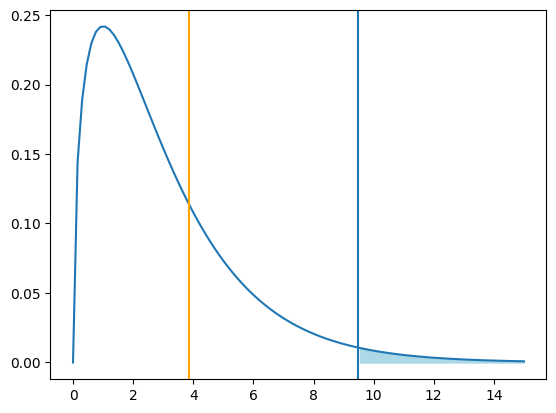

In [7]:
# x-values:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with 4 degrees of freedom
y = stats.chi2.pdf(x, df=dof)
# the number q for which the right tail probability is exactly 5%:
q = stats.chi2.isf(alpha, df=4)  # TODO: CHECK this!

fig, tplot = plt.subplots(1, 1)
tplot.plot(x, y)                     # probability density
tplot.fill_between(x, y, where=x>=q, # critical area
    color='lightblue')
tplot.axvline(q)                     # critical value
tplot.axvline(chi2, color='orange')  # chi-squared

### Gender vs Preference

In [8]:
observed = pd.crosstab(df.Preference, df.Gender)
observed

Gender,F,M
Preference,,
Competing brand,90,26
Our brand,94,40


In [9]:
chi2, p, dof, expected = stats.chi2_contingency(observed)

g = stats.chi2.isf(alpha, df = dof)

print("Chi-squared          : %.4f" % chi2)
print("Degrees of freedom   : %.4f" % dof)
print("P-value              : %.4f" % p)
print("Critical value       : %.4f" % g)

Chi-squared          : 1.4078
Degrees of freedom   : 1.0000
P-value              : 0.2354
Critical value       : 3.8415


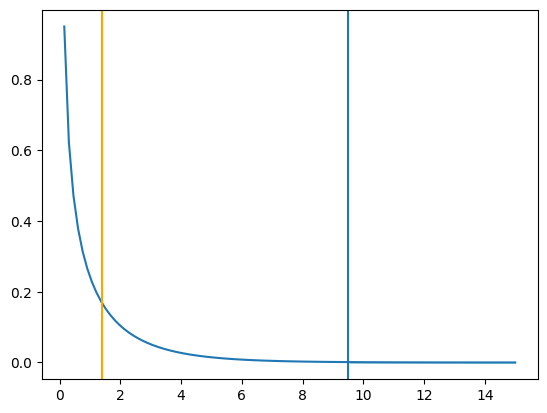

In [10]:
# x-values:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with 4 degrees of freedom
y = stats.chi2.pdf(x, df=dof)
# the number q for which the right tail probability is exactly 5%:
q = stats.chi2.isf(alpha, df=4)  # TODO: CHECK this!

fig, tplot = plt.subplots(1, 1)
tplot.plot(x, y)                     # probability density
tplot.fill_between(x, y, where=x>=q, # critical area
    color='lightblue')
tplot.axvline(q)                     # critical value
tplot.axvline(chi2, color='orange')  # chi-squared